In [95]:
## The goal of this notebook is to study the applicability of private (non-)membership proof delegation
## in a stateless blockchain application. The empirical data is taken from here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm
import matplotlib.colors as colors

In [97]:
## Transaction per second that we want to simulate
## We roughly both want to capture Bitcoin (7 tps), Ethereum's throguhput with L2s (100 tps roughly) and VISA/Mastercard (10k tps)
tps = [2**i for i in range(1, 7)]
## Offline-time interval length (this is the offline period length that we can support)
server_time = [
    2**i for i in range(1, 28, 4)
]  ## in hours (the PSN server is running for this many hours to do its job)

In [98]:
## Bitcoin's empirical coin age follows a power-law distribution
## See the data and measurements here: https://insights.glassnode.com/time-is-money-how-coin-age-shapes-bitcoins-spending-patterns/
## This power-law distribution can be approximated with the following line on a log-log scale
intercept = -1.4159
slope = -0.9550
## To ease calculations let's just compute with the average of this distribution
average_coin_age_days = (
    162  ## in days (this is a rough estimation given the empirical data above)
)
## median_coin_age_days = 40 //average 162
average_coin_age_hours = average_coin_age_days * 24
average_coin_age_seconds = average_coin_age_hours * 60 * 60  ## in seconds
miliSecondsInHour = 3600000
hoursInMonth = 731

In [99]:
tx3_large_cost_per_hour = 0.208  # in USD, from https://calculator.aws/#/createCalculator/ec2-enhancement on 2026-04-09

In [100]:
bilinear_running_times = [
    1.593770,
    3.538859,
    9.606699,
    26.058632,
    65.352250,
    131.966387,
    274.302579,
    790.240733,
]  ## in miliseconds
y = [math.log2(i) for i in bilinear_running_times]
x = [i + 3 for i in range(len(y))]
print(x)
print(y)
## Linear regression results on the data above (R^2=0.9990)
intercept_runtimes = -2.4808
slope_runtimes = 1.0367

[3, 4, 5, 6, 7, 8, 9, 10]
[0.6724434462662564, 1.8232842811038672, 3.2640407853757254, 4.703689443619993, 6.0301650020322075, 7.044026699027231, 8.099624376281072, 9.626148401798412]


In [101]:
print(tps)

[2, 4, 8, 16, 32, 64]


In [102]:
## Bilinear membership proof-delegation
noOfThreads = 8  ## number of threads at the AWS server machine
crs_length = (
    2**28
)  ## currently, this is the largest Powers-of-tau trusted setup that one could use in an application without relying on an entirely new trusted setup ceremony
g1_group_element_size = 384  ## in bits
bilinear_upd_cost = np.zeros((len(tps), len(server_time)))
bilinear_comm_complexity = np.zeros((len(tps), len(server_time)))
for i in range(0, len(tps)):
    for j in range(0, len(server_time)):
        ## for each coin, there were this many new coins added to the UTXO set meanwhile it had not been spent
        necessaryUpdatesPerCoin = average_coin_age_seconds * tps[i]
        if (
            necessaryUpdatesPerCoin < crs_length
        ):  ##otherwise, it would not even be possible to do the membership proof update
            updates_per_threads = (
                tps[i]
                * (
                    slope_runtimes * (math.log2(necessaryUpdatesPerCoin))
                    + intercept_runtimes
                )
            ) / noOfThreads
            ## the runtime above were given in miliseconds, thus we need to convert them to hour
            upd_cost_per_hour = (
                updates_per_threads / miliSecondsInHour
            )  ## the workload can be done in parallel
            bilinear_upd_cost[i, j] = (
                upd_cost_per_hour * tx3_large_cost_per_hour * server_time[j]
            )  ## let's assume the server is running for 1 year=12 months
            bilinear_comm_complexity[i, j] = (
                server_time[j] * 0.000013 * tps[i]
            )  ##in PB. for each user a client needs to communicate 12.885GB=384*(2**28) bits
bilinear_upd_cost

array([[6.69231336e-07, 1.07077014e-05, 1.71323222e-04, 2.74117155e-03,
        4.38587448e-02, 7.01739917e-01, 1.12278387e+01],
       [1.39836089e-06, 2.23737743e-05, 3.57980389e-04, 5.72768622e-03,
        9.16429795e-02, 1.46628767e+00, 2.34606028e+01],
       [2.91651823e-06, 4.66642917e-05, 7.46628667e-04, 1.19460587e-02,
        1.91136939e-01, 3.05819102e+00, 4.89310563e+01],
       [6.07262935e-06, 9.71620696e-05, 1.55459311e-03, 2.48734898e-02,
        3.97975837e-01, 6.36761340e+00, 1.01881814e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

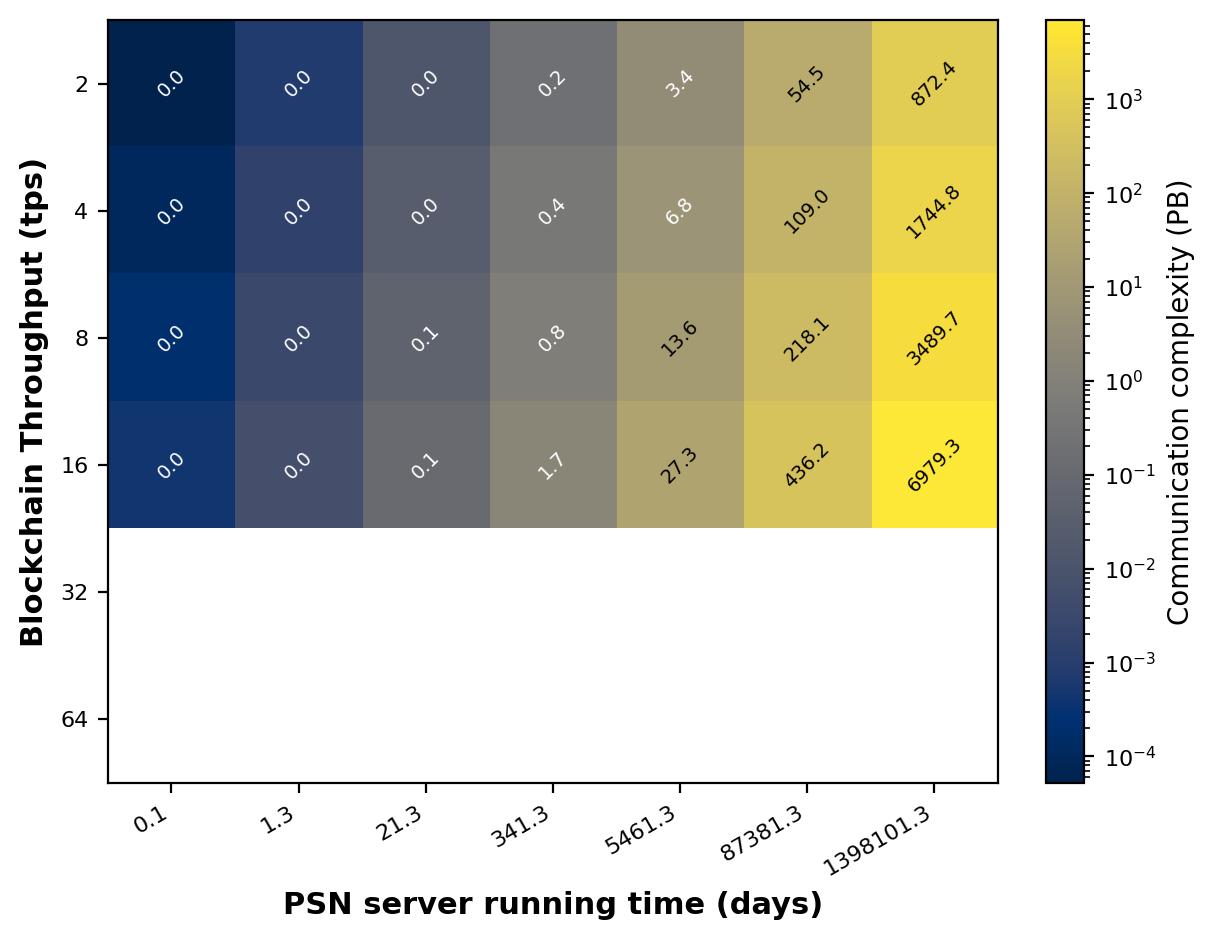

In [103]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

comm_for_plot = np.where(bilinear_comm_complexity > 0, bilinear_comm_complexity, np.nan)
vmin = float(np.nanmin(comm_for_plot))
vmax = float(np.nanmax(comm_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    comm_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.1f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

# Add subtle cell boundaries for easier reading in print.
ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = bilinear_comm_complexity[i, j]
        if value <= 0:
            continue

        label = f"{round(value, 2):.1f}"  # if value >= 1 else f"{round(value, 2):.1e}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Communication complexity (PB)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_bilinear_comm_complexity.pdf", bbox_inches="tight")
plt.show()

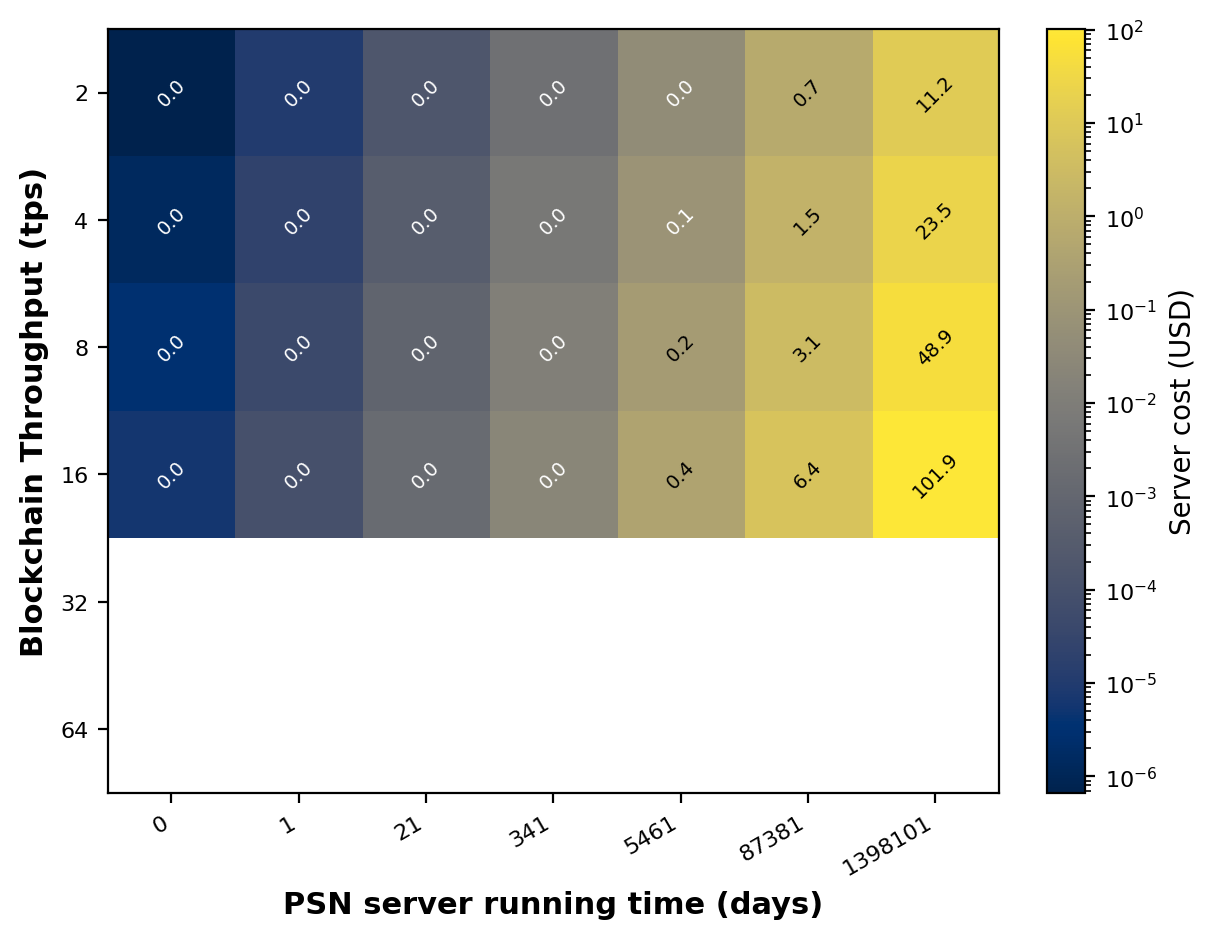

In [104]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

cost_for_plot = np.where(bilinear_upd_cost > 0, bilinear_upd_cost, np.nan)
vmin = float(np.nanmin(cost_for_plot))
vmax = float(np.nanmax(cost_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    cost_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.0f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = bilinear_upd_cost[i, j]
        if value <= 0:
            continue

        label = f"{value:.1f}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Server cost (USD)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_bilinear.pdf", bbox_inches="tight")
plt.show()

In [105]:
## RSA membership proof-delegation

In [106]:
rsa_running_times = [
    165.62647694999998,
    260.1670167,
    439.2490581,
    839.2848875,
    1562.574625,
    3043.0599419,
    3441.5449793000003,
    6883.0211207,
]  ## in miliseconds
y = [math.log2(i) for i in rsa_running_times]
x = [i + 3 for i in range(len(y))]
print(x)
print(y)
## Linear regression results on the data above (R^2=0.9990)
intercept_runtimes = -2.4808
slope_runtimes = 1.0367

[3, 4, 5, 6, 7, 8, 9, 10]
[7.371789509418317, 8.023294262285635, 8.778895382380792, 9.713016793073328, 10.609709375906611, 11.57130703686167, 11.74884065005245, 12.748826221562604]


In [107]:
## RSA membership proof-delegation
noOfThreads = 8  ## number of threads at the AWS server machine
crs_length = 2**28
g1_group_element_size = 3072  ## in bits
rsa_upd_cost = np.zeros((len(tps), len(server_time)))
rsa_comm_complexity = np.zeros((len(tps), len(server_time)))
for i in range(0, len(tps)):
    for j in range(0, len(server_time)):
        ## for each coin, there were this many new coins added to the UTXO set meanwhile it had not been spent
        necessaryUpdatesPerCoin = average_coin_age_seconds * tps[i]
        if (
            True
        ):  ##otherwise, it would not even be possible to do the membership proof update
            updates_per_threads = (
                tps[i]
                * (
                    slope_runtimes * (math.log2(necessaryUpdatesPerCoin))
                    + intercept_runtimes
                )
            ) / noOfThreads
            ## the runtime above were given in miliseconds, thus we need to convert them to hour
            upd_cost_per_hour = (
                updates_per_threads / miliSecondsInHour
            )  ## the workload can be done in parallel
            rsa_upd_cost[i, j] = (
                upd_cost_per_hour * tx3_large_cost_per_hour * server_time[j]
            )  ## let's assume the server is running for 1 year=12 months
            rsa_comm_complexity[i, j] = (
                server_time[j] * 0.000013 * tps[i]
            )  ##in PB. for each user a client needs to communicate =3072*(2**28) bits
rsa_upd_cost

array([[6.69231336e-07, 1.07077014e-05, 1.71323222e-04, 2.74117155e-03,
        4.38587448e-02, 7.01739917e-01, 1.12278387e+01],
       [1.39836089e-06, 2.23737743e-05, 3.57980389e-04, 5.72768622e-03,
        9.16429795e-02, 1.46628767e+00, 2.34606028e+01],
       [2.91651823e-06, 4.66642917e-05, 7.46628667e-04, 1.19460587e-02,
        1.91136939e-01, 3.05819102e+00, 4.89310563e+01],
       [6.07262935e-06, 9.71620696e-05, 1.55459311e-03, 2.48734898e-02,
        3.97975837e-01, 6.36761340e+00, 1.01881814e+02],
       [1.26244445e-05, 2.01991112e-04, 3.23185779e-03, 5.17097246e-02,
        8.27355594e-01, 1.32376895e+01, 2.11803032e+02],
       [2.62072605e-05, 4.19316168e-04, 6.70905869e-03, 1.07344939e-01,
        1.71751903e+00, 2.74803044e+01, 4.39684871e+02]])

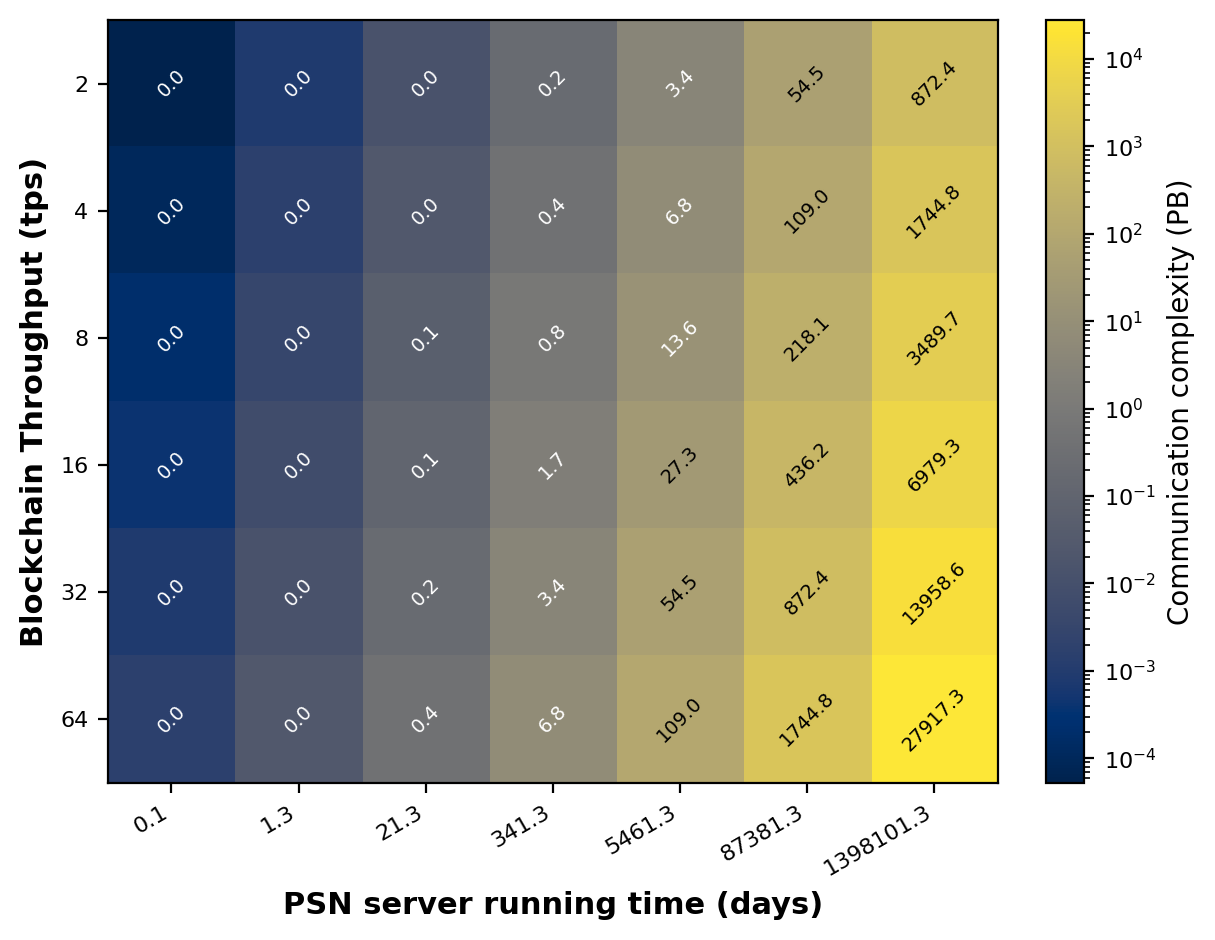

In [ ]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

comm_for_plot = np.where(rsa_comm_complexity > 0, rsa_comm_complexity, np.nan)
vmin = float(np.nanmin(comm_for_plot))
vmax = float(np.nanmax(comm_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    comm_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.1f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

# Add subtle cell boundaries for easier reading in print.
ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = rsa_comm_complexity[i, j]
        if value <= 0:
            continue

        label = f"{round(value, 2):.0f}"  # if value >= 1 else f"{round(value, 2):.1e}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Communication complexity (PB)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_rsa_comm_complexity.pdf", bbox_inches="tight")
plt.show()

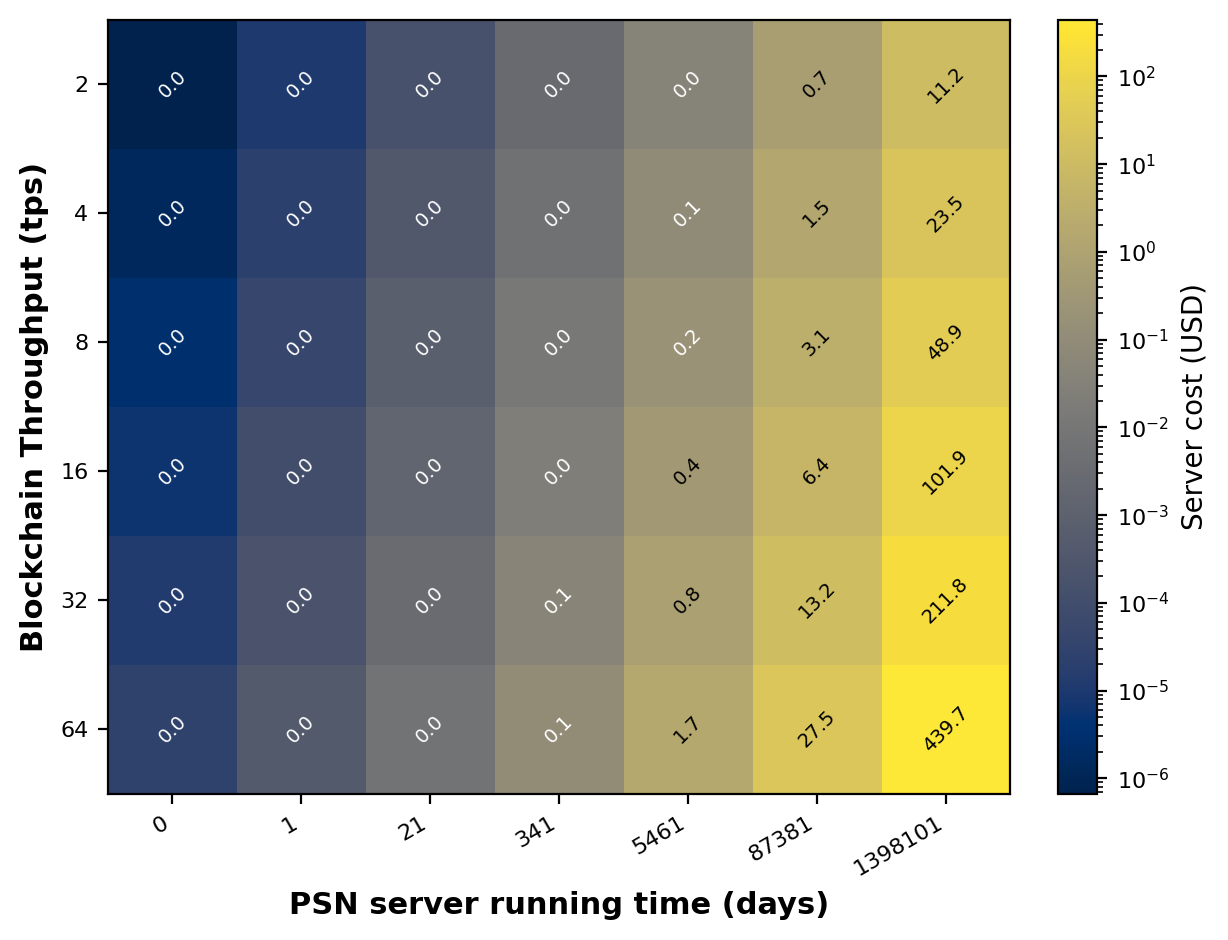

In [109]:
import matplotlib.patheffects as pe
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = plt.cm.cividis.copy()
cmap.set_bad("white", alpha=1.0)
cmap.set_under("white", alpha=1.0)

cost_for_plot = np.where(rsa_upd_cost > 0, rsa_upd_cost, np.nan)
vmin = float(np.nanmin(cost_for_plot))
vmax = float(np.nanmax(cost_for_plot))
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    cost_for_plot,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

day_labels = [f"{h / 24:.0f}" for h in server_time]

ax.set_ylabel("Blockchain Throughput (tps)", fontweight="bold", fontsize=11)
ax.set_xlabel("PSN server running time (days)", fontweight="bold", fontsize=11)
ax.set_yticks(range(len(tps)))
ax.set_yticklabels([str(x) for x in tps], fontsize=8)
ax.set_xticks(range(len(server_time)))
ax.set_xticklabels(day_labels, rotation=30, ha="right", fontsize=8)

ax.set_xticks(np.arange(0, len(server_time), 1), minor=True)
ax.set_yticks(np.arange(0, len(tps), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(len(tps)):
    for j in range(len(server_time)):
        value = rsa_upd_cost[i, j]
        if value <= 0:
            continue

        label = f"{value:.1f}"
        rgba = cmap(norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.58 else "white"
        stroke_color = "white" if text_color == "black" else "black"

        text = ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            rotation=45,
        )

cbar = plt.colorbar(im, label="Server cost (USD)", fraction=0.046, pad=0.04)
cbar.locator = ticker.LogLocator(base=10)
cbar.formatter = ticker.LogFormatterMathtext(base=10)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.savefig("./images/case_study_rsa_upd_cost.pdf", bbox_inches="tight")
plt.show()